# Daily Sports and Activities: Multi-view Stacking

# 1. Base de datos

La base de datos se puede obtener en el siguiente enlace: 

https://archive.ics.uci.edu/dataset/256/daily+and+sports+activities

El artículo del paper se puede obtener en el siguiente enlace: 

https://yoksis.bilkent.edu.tr/pdf/files/10.1016-j.patcog.2010.04.019.pdf

The 19 activities are: 

- sitting (A1), 
- standing (A2), 
- lying on back and on right side (A3 and A4), 
- ascending and descending stairs (A5 and A6), 
- standing in an elevator still (A7) 
- and moving around in an elevator (A8), 
- walking in a parking lot (A9), 
- walking on a treadmill with a speed of 4 km/h (in flat and 15 deg inclined positions) (A10 and A11),
- running on a treadmill with a speed of 8 km/h (A12), 
- exercising on a stepper (A13), 
- exercising on a cross trainer (A14), 
- cycling on an exercise bike in horizontal and vertical positions (A15 and A16),
- rowing (A17), 
- jumping (A18), 
- and playing basketball (A19).

# 2. Método

## 2.1. Cargar los datos

In [8]:
import pandas as pd
pd.set_option("display.float_format", "{:.3f}".format)

import os

from abc import ABC, abstractmethod

class AbstractDataLoader(ABC):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        self.src_path = src_path
        self.keys = keys
        self.file_extension = file_extension
        self.delimiter = delimiter     
        
    @abstractmethod
    def load_data(self):
        pass

    @abstractmethod
    def _is_valid_extension(self, file):
        pass


class DataLoaderDSA(AbstractDataLoader):
    def __init__(self, src_path:str, keys:list, file_extension:str, delimiter:str):
        super().__init__(src_path, keys, file_extension, delimiter)
        
    
    def load_data(self):
        dataframes = []
        for activity in os.listdir(self.src_path):
            act_path = f"{self.src_path}/{activity}"
            for person in os.listdir(act_path):
                person_path = f"{self.src_path}/{activity}/{person}"
                for segment in os.listdir(person_path):
                    segment_path = f"{self.src_path}/{activity}/{person}/{segment}"
                    if self._is_valid_extension(segment):  
                        segment_features = pd.read_csv(segment_path, delimiter=self.delimiter, names=self.keys)
                        segment_features['activity_label'] = activity
                        segment_features['person_id'] = person
                        segment_features['segment'] = f"{activity}{person}{segment}"
                        dataframes.append(segment_features)
        final_df = pd.concat(dataframes, ignore_index=True)
        return final_df
    
                
    def _is_valid_extension(self, file):
        return file.endswith(self.file_extension)


dsa_path = "dataset/dsaa/data"

keys = [
    # Tronco (T)
    "T_xacc", "T_yacc", "T_zacc", "T_xgyro", "T_ygyro", "T_zgyro", "T_xmag", "T_ymag", "T_zmag",
    
    # Brazo derecho (RA)
    "RA_xacc", "RA_yacc", "RA_zacc", "RA_xgyro", "RA_ygyro", "RA_zgyro", "RA_xmag", "RA_ymag", "RA_zmag",
    
    # Brazo izquierdo (LA)
    "LA_xacc", "LA_yacc", "LA_zacc", "LA_xgyro", "LA_ygyro", "LA_zgyro", "LA_xmag", "LA_ymag", "LA_zmag",
    
    # Pierna derecha (RL)
    "RL_xacc", "RL_yacc", "RL_zacc", "RL_xgyro", "RL_ygyro", "RL_zgyro", "RL_xmag", "RL_ymag", "RL_zmag",
    
    # Pierna izquierda (LL)
    "LL_xacc", "LL_yacc", "LL_zacc", "LL_xgyro", "LL_ygyro", "LL_zgyro", "LL_xmag", "LL_ymag", "LL_zmag"
]

file_extension = '.txt'
delimiter = r','
data_loader = DataLoaderDSA(dsa_path, keys, file_extension, delimiter)

dsa_df = data_loader.load_data()

In [9]:
dsa_df.head()

,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,T_ymag,T_zmag,RA_xacc,...,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,activity_label,person_id,segment
0,8.130,1.035,5.422,-0.009,0.002,-0.003,-0.787,-0.070,0.157,0.701,...,2.622,-0.000,-0.012,-0.004,0.740,0.301,-0.058,a01,p1,a01p1s01.txt
1,8.130,1.020,5.384,-0.009,0.023,0.002,-0.787,-0.068,0.159,0.718,...,2.622,-0.015,-0.016,0.003,0.739,0.302,-0.058,a01,p1,a01p1s01.txt
2,8.160,1.020,5.362,0.015,0.014,0.000,-0.787,-0.068,0.159,0.698,...,2.637,-0.013,0.006,-0.008,0.740,0.301,-0.057,a01,p1,a01p1s01.txt
3,8.160,1.005,5.377,0.007,0.018,0.006,-0.785,-0.070,0.159,0.728,...,2.607,-0.006,0.010,0.007,0.740,0.302,-0.058,a01,p1,a01p1s01.txt
4,8.161,1.028,5.347,0.009,0.030,-0.005,-0.787,-0.069,0.159,0.716,...,2.622,-0.004,-0.008,0.003,0.738,0.301,-0.058,a01,p1,a01p1s01.txt


## 2.2. Pre-proceso

Aplicamos filtro de mediana

In [12]:
non_sensor_columns = ["activity_label", "person_id", "segment"]
only_sensor_columns = dsa_df.drop(non_sensor_columns, axis="columns")

In [13]:
import numpy as np
import pandas as pd
from scipy.signal import medfilt
from scipy.ndimage import gaussian_filter1d

# First apply median filter
only_sensor_columns_filtered = only_sensor_columns.apply(lambda col: medfilt(col, kernel_size=3))


# Combine non-sensor and filtered sensor data
dsaa_no_outlier = pd.concat([dsa_df[non_sensor_columns], only_sensor_columns_filtered], axis=1)

dsaa_no_outlier

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,RL_zmag,LL_xacc,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-0.034,-2.807,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-0.036,-2.815,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-0.036,-2.807,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,-0.068,-10.752,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,-0.063,-5.184,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,-0.063,-3.648,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,-0.195,-1.035,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489


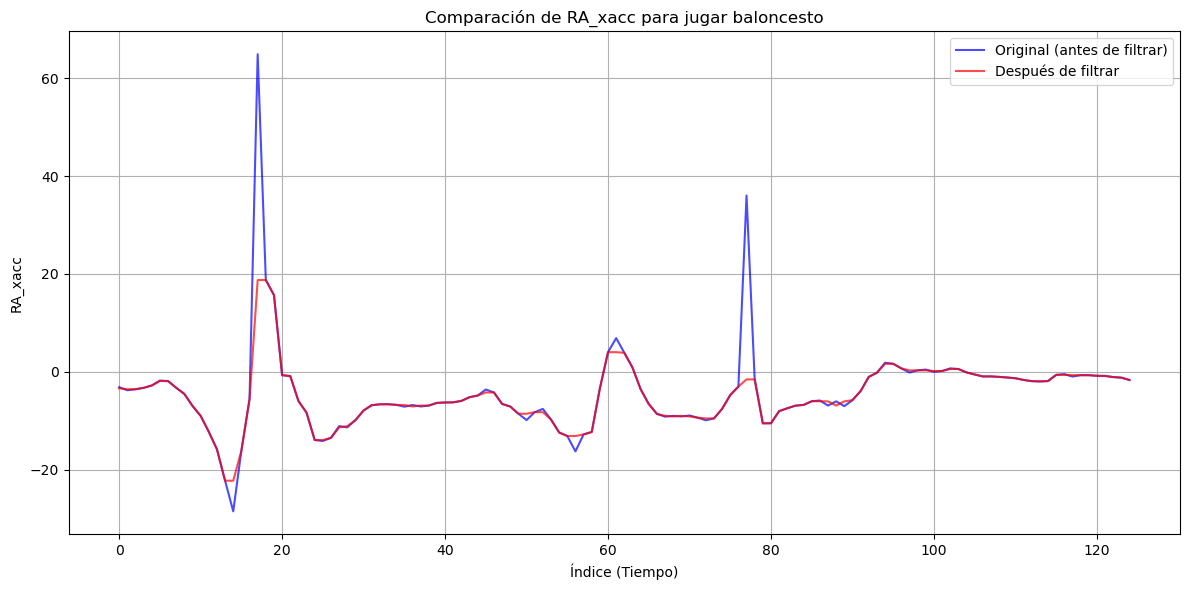

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Define la columna que deseas graficar
columna = 'RA_xacc'  # Cambia este valor para usar otra columna

# Ejemplo: selecciona solo el segmento y persona especificados
segmento_elegido = 'a19p1s03.txt'
persona_elegida = 'p1'

# Filtrar el DataFrame original (dsa_df) y el filtrado (dsaa_no_outlier)
df_original = dsa_df[(dsa_df['segment'] == segmento_elegido) & (dsa_df['person_id'] == persona_elegida)]
df_filtrado = dsaa_no_outlier[(dsaa_no_outlier['segment'] == segmento_elegido) & (dsaa_no_outlier['person_id'] == persona_elegida)]

# Reiniciar índice para asegurar la consistencia al graficar
df_original = df_original.reset_index(drop=True)
df_filtrado = df_filtrado.reset_index(drop=True)

# Ajustar la longitud de ambos DataFrame al mínimo común
min_len = min(len(df_original), len(df_filtrado))
df_original = df_original.iloc[:min_len]
df_filtrado = df_filtrado.iloc[:min_len]

# Graficar la columna elegida de ambos DataFrame
plt.figure(figsize=(12, 6))
plt.plot(df_original[columna], label='Original (antes de filtrar)', color='blue', alpha=0.7)
plt.plot(df_filtrado[columna], label='Después de filtrar', color='red', alpha=0.7)
plt.title(f'Comparación de {columna} para jugar baloncesto')
plt.xlabel('Índice (Tiempo)')
plt.ylabel(columna)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 2.3. Segmentación

In [16]:
def segmentar_por_3s(df, window_size=75):
    df_segmentado_list = []
    
    # Agrupamos por actividad y persona
    for (actividad, persona), grupo in df.groupby(['activity_label', 'person_id']):
        # Calculamos cuántas ventanas completas se pueden formar en este grupo
        n_segmentos = len(grupo) // window_size
        
        # Si no hay suficientes filas para una ventana completa, se omite este grupo
        if n_segmentos == 0:
            continue
        
        # Seleccionamos solo las filas que completan ventanas completas
        grupo_completo = grupo.iloc[:n_segmentos * window_size].copy()
        grupo_completo.reset_index(drop=True, inplace=True)
        
        # Creamos un índice de segmento para cada ventana
        grupo_completo['segment_index'] = grupo_completo.index // window_size
        
        # Generamos el identificador único concatenando actividad, persona y el índice del segmento
        grupo_completo['segment_3s'] = grupo_completo.apply(
            lambda row: f"{actividad}{persona}{int(row['segment_index'])}", axis=1
        )
        
        df_segmentado_list.append(grupo_completo)
    
    # Concatenamos todos los grupos procesados en un único DataFrame
    return pd.concat(df_segmentado_list, ignore_index=True)

df_unsegmented = dsaa_no_outlier

dsaa_no_outlier3 = segmentar_por_3s(df_unsegmented)
dsaa_no_outlier3

,activity_label,person_id,segment,T_xacc,T_yacc,T_zacc,T_xgyro,T_ygyro,T_zgyro,T_xmag,...,LL_yacc,LL_zacc,LL_xgyro,LL_ygyro,LL_zgyro,LL_xmag,LL_ymag,LL_zmag,segment_index,segment_3s
0,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.002,0.000,-0.787,...,-9.074,2.622,-0.000,-0.012,0.000,0.739,0.301,-0.058,0,a01p10
1,a01,p1,a01p1s01.txt,8.130,1.020,5.384,-0.009,0.014,0.000,-0.787,...,-9.081,2.622,-0.013,-0.012,-0.004,0.740,0.301,-0.058,0,a01p10
2,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.018,0.002,-0.787,...,-9.081,2.622,-0.013,0.006,0.003,0.740,0.302,-0.058,0,a01p10
3,a01,p1,a01p1s01.txt,8.160,1.020,5.362,0.009,0.018,0.000,-0.787,...,-9.081,2.622,-0.006,0.006,0.003,0.740,0.301,-0.058,0,a01p10
4,a01,p1,a01p1s01.txt,8.160,1.020,5.377,0.007,0.030,-0.005,-0.787,...,-9.081,2.607,-0.006,0.010,0.003,0.740,0.301,-0.058,0,a01p10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1139995,a19,p8,a19p8s60.txt,16.008,-2.017,0.487,2.027,1.604,0.584,-0.731,...,2.809,-4.593,-0.231,0.181,-2.082,0.569,0.394,0.518,99,a19p899
1139996,a19,p8,a19p8s60.txt,8.282,-0.699,0.487,2.027,1.604,-0.020,-0.731,...,4.323,-4.111,1.817,0.313,-1.022,0.538,0.437,0.504,99,a19p899
1139997,a19,p8,a19p8s60.txt,2.712,-0.699,0.487,1.996,1.466,-0.073,-0.725,...,1.255,-4.111,1.817,0.349,-0.368,0.518,0.473,0.489,99,a19p899
1139998,a19,p8,a19p8s60.txt,2.031,0.500,-0.113,1.996,1.010,-0.073,-0.719,...,15.054,1.294,-0.150,0.349,-0.368,0.504,0.473,0.489,99,a19p899


In [17]:
dsaa_no_outlier3.columns

Index(['activity_label', 'person_id', 'segment', 'T_xacc', 'T_yacc', 'T_zacc',
       'T_xgyro', 'T_ygyro', 'T_zgyro', 'T_xmag', 'T_ymag', 'T_zmag',
       'RA_xacc', 'RA_yacc', 'RA_zacc', 'RA_xgyro', 'RA_ygyro', 'RA_zgyro',
       'RA_xmag', 'RA_ymag', 'RA_zmag', 'LA_xacc', 'LA_yacc', 'LA_zacc',
       'LA_xgyro', 'LA_ygyro', 'LA_zgyro', 'LA_xmag', 'LA_ymag', 'LA_zmag',
       'RL_xacc', 'RL_yacc', 'RL_zacc', 'RL_xgyro', 'RL_ygyro', 'RL_zgyro',
       'RL_xmag', 'RL_ymag', 'RL_zmag', 'LL_xacc', 'LL_yacc', 'LL_zacc',
       'LL_xgyro', 'LL_ygyro', 'LL_zgyro', 'LL_xmag', 'LL_ymag', 'LL_zmag',
       'segment_index', 'segment_3s'],
      dtype='object')

In [18]:
dsaa_no_outlier3.dtypes

activity_label     object
person_id          object
segment            object
T_xacc            float64
T_yacc            float64
T_zacc            float64
T_xgyro           float64
T_ygyro           float64
T_zgyro           float64
T_xmag            float64
T_ymag            float64
T_zmag            float64
RA_xacc           float64
RA_yacc           float64
RA_zacc           float64
RA_xgyro          float64
RA_ygyro          float64
RA_zgyro          float64
RA_xmag           float64
RA_ymag           float64
RA_zmag           float64
LA_xacc           float64
LA_yacc           float64
LA_zacc           float64
LA_xgyro          float64
LA_ygyro          float64
LA_zgyro          float64
LA_xmag           float64
LA_ymag           float64
LA_zmag           float64
RL_xacc           float64
RL_yacc           float64
RL_zacc           float64
RL_xgyro          float64
RL_ygyro          float64
RL_zgyro          float64
RL_xmag           float64
RL_ymag           float64
RL_zmag     

In [19]:
dsaa_no_outlier3.groupby(['activity_label', 'person_id'])['segment_3s'].nunique()

activity_label  person_id
a01             p1           100
                p2           100
                p3           100
                p4           100
                p5           100
                            ... 
a19             p4           100
                p5           100
                p6           100
                p7           100
                p8           100
Name: segment_3s, Length: 152, dtype: int64

## 2.4. Extracción de características

In [21]:
import numpy as np

class InertialSensor:
    def __init__(self, x, y, z):
        """
        Inicializa el acelerómetro con sus 3 señales.
        
        Parámetros:
          x: array-like, señal del eje x.
          y: array-like, señal del eje y.
          z: array-like, señal del eje z.
        """
        self.x = np.array(x)
        self.y = np.array(y)
        self.z = np.array(z)
        
    def compute_magnitude(self):
        return np.sqrt(self.x**2 + self.y**2 + self.z**2)
    
    def extract_features(self):
        # 1. Medias de cada eje
        mean_x = np.mean(self.x)
        mean_y = np.mean(self.y)
        mean_z = np.mean(self.z)
        
        # 2. Desviaciones estándar
        std_x = np.std(self.x)
        std_y = np.std(self.y)
        std_z = np.std(self.z)
        
        # 3. Valores máximos
        max_x = np.max(self.x)
        max_y = np.max(self.y)
        max_z = np.max(self.z)
        
        # 4. Correlaciones entre cada par de ejes
        corr_xy = np.corrcoef(self.x, self.y)[0, 1]
        corr_xz = np.corrcoef(self.x, self.z)[0, 1]
        corr_yz = np.corrcoef(self.y, self.z)[0, 1]
        
        # 5,6,7,8. Features derivadas de la magnitud
        magnitude = self.compute_magnitude()
        mean_magnitude = np.mean(magnitude)
        std_magnitude = np.std(magnitude)
        auc = np.sum(magnitude)
        mean_diff = np.mean(np.diff(magnitude)) if len(magnitude) > 1 else 0.0
        
        # Vector de features
        feature_vector = np.array([
            mean_x, mean_y, mean_z,
            std_x, std_y, std_z,
            max_x, max_y, max_z,
            corr_xy, corr_xz, corr_yz,
            mean_magnitude, std_magnitude, auc, mean_diff
        ])
        
        return feature_vector

In [22]:
import numpy as np
import pandas as pd

# Assume dsaa_no_outlier3 has a column 'person_id'
df_to_extract_features = dsaa_no_outlier3

numeric_features_list = []
labels = []
person_ids = []  # new list to collect person IDs

for seg, group in df_to_extract_features.groupby("segment_3s"):
    # Extract person ID (assuming column named 'person_id')
    pid = group["person_id"].iloc[0]

    # Torso
    T_features = InertialSensor(group.T_xacc, group.T_yacc, group.T_zacc).extract_features()
    T_gyro_features = InertialSensor(group.T_xgyro, group.T_ygyro, group.T_zgyro).extract_features()
    T_mag_features = InertialSensor(group.T_xmag, group.T_ymag, group.T_zmag).extract_features()

    # Right Arm
    RA_features = InertialSensor(group.RA_xacc, group.RA_yacc, group.RA_zacc).extract_features()
    RA_gyro_features = InertialSensor(group.RA_xgyro, group.RA_ygyro, group.RA_zgyro).extract_features()
    RA_mag_features = InertialSensor(group.RA_xmag, group.RA_ymag, group.RA_zmag).extract_features()

    # Left Arm
    LA_features = InertialSensor(group.LA_xacc, group.LA_yacc, group.LA_zacc).extract_features()
    LA_gyro_features = InertialSensor(group.LA_xgyro, group.LA_ygyro, group.LA_zgyro).extract_features()
    LA_mag_features = InertialSensor(group.LA_xmag, group.LA_ymag, group.LA_zmag).extract_features()

    # Right Leg
    RL_features = InertialSensor(group.RL_xacc, group.RL_yacc, group.RL_zacc).extract_features()
    RL_gyro_features = InertialSensor(group.RL_xgyro, group.RL_ygyro, group.RL_zgyro).extract_features()
    RL_mag_features = InertialSensor(group.RL_xmag, group.RL_ymag, group.RL_zmag).extract_features()

    # Left Leg
    LL_features = InertialSensor(group.LL_xacc, group.LL_yacc, group.LL_zacc).extract_features()
    LL_gyro_features = InertialSensor(group.LL_xgyro, group.LL_ygyro, group.LL_zgyro).extract_features()
    LL_mag_features = InertialSensor(group.LL_xmag, group.LL_ymag, group.LL_zmag).extract_features()
    
    # Combine all feature sets into one row and convert numeric values to float
    feature_vector = np.concatenate([
        T_features, T_gyro_features, T_mag_features,
        RA_features, RA_gyro_features, RA_mag_features,
        LA_features, LA_gyro_features, LA_mag_features,
        RL_features, RL_gyro_features, RL_mag_features,
        LL_features, LL_gyro_features, LL_mag_features
    ]).astype(float)
    
    numeric_features_list.append(feature_vector)
    labels.append(group["activity_label"].iloc[0])
    person_ids.append(pid)  # add the person ID to the list

# Generate feature column names
sensor_locations = ["T", "RA", "LA", "RL", "LL"]
sensor_types = ["acc", "gyro", "mag"]
feature_names = [
    "mean_x", "mean_y", "mean_z", "std_x", "std_y", "std_z",
    "max_x", "max_y", "max_z", "corr_xy", "corr_xz", "corr_yz",
    "mean_mag", "std_mag", "auc", "mean_diff"
]

feature_columns = [
    f"{loc}_{typ}_{feat}"
    for loc in sensor_locations
    for typ in sensor_types
    for feat in feature_names
]

# Create DataFrame for numeric features and convert to float
df_numeric = pd.DataFrame(np.array(numeric_features_list), columns=feature_columns)

# Create DataFrame for labels
df_labels = pd.DataFrame(labels, columns=["activity"])

# Create DataFrame for person IDs
df_person_id = pd.DataFrame(person_ids, columns=["person_id"])

# Concatenate numeric features, labels, and person IDs
examples = pd.concat([df_numeric, df_labels, df_person_id], axis=1)

# Optionally, check the first few rows and data types
display(examples.head())
display(examples.dtypes)

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1


T_acc_mean_x        float64
T_acc_mean_y        float64
T_acc_mean_z        float64
T_acc_std_x         float64
T_acc_std_y         float64
                     ...   
LL_mag_std_mag      float64
LL_mag_auc          float64
LL_mag_mean_diff    float64
activity             object
person_id            object
Length: 242, dtype: object

In [23]:
examples

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,-0.027,0.511,-0.086,-0.450,0.861,0.047,64.589,0.001,a19,p8
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,0.667,-0.264,-0.735,-0.106,0.930,0.016,69.735,0.000,a19,p8
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,0.675,-0.362,-0.941,0.523,0.932,0.013,69.889,0.000,a19,p8
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,0.626,-0.206,-0.812,-0.356,0.912,0.008,68.395,-0.000,a19,p8


## 2.5. Entrenamiento

## 2.5.1. 10-Fold Cross Validation

Pipeline para evaluar el desempeño de un modelo

In [27]:
import numpy as np
from scipy import stats
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

def pipelinear_crossvalidation(model, X, y):
    """
    Ajusta un pipeline (scaler + model) con CV de 10 folds estratificada y reproducible.
    Muestra estadísticas de F1-macro, accuracy, precision-macro y recall-macro,
    controlando explicitamente zero_division=0.
    """
    # 1) Creamos los scorers con zero_division=0
    precision_macro_zd = make_scorer(
        precision_score,
        average='macro',
        zero_division=0
    )
    recall_macro_zd = make_scorer(
        recall_score,
        average='macro',
        zero_division=0
    )
    f1_macro_zd = make_scorer(
        f1_score,
        average='macro',
        zero_division=0
    )
    # accuracy no necesita zero_division
    accuracy_scorer = 'accuracy'

    # 2) Pipeline con escalado y modelo
    scaler = StandardScaler()
    pipe = make_pipeline(scaler, model)

    # 3) Validación cruzada estratificada y reproducible
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    cv_results = cross_validate(
        estimator=pipe,
        X=X, y=y,
        cv=cv,
        scoring={
            "f1_macro":        f1_macro_zd,
            "accuracy":        accuracy_scorer,
            "precision_macro": precision_macro_zd,
            "recall_macro":    recall_macro_zd
        },
        return_train_score=False
    )

    # 4) Recolectar resultados por fold
    scores = cv_results["test_f1_macro"]
    times  = cv_results["fit_time"]

    all_scores = []
    for i in range(cv.get_n_splits()):
        fold_scores = {
            "f1_macro":         cv_results["test_f1_macro"][i],
            "accuracy":         cv_results["test_accuracy"][i],
            "precision_macro":  cv_results["test_precision_macro"][i],
            "recall_macro":     cv_results["test_recall_macro"][i]
        }
        all_scores.append(fold_scores)

    # 5) Función auxiliar para estadísticos
    def stats_arr(arr):
        return {
            "Media:":     np.mean(arr),
            "Mediana:":   np.median(arr),
            "Std:":       np.std(arr),
            "Mínimo:":    np.min(arr),
            "Máximo:":    np.max(arr),
        }

    stats_scores = stats_arr(scores)
    stats_times  = stats_arr(times)

    # 6) Impresión de resultados
    print("Scores (F1-macro):")
    for i in range(0, len(scores), 5):
        print("  " + "  ".join(f"{s:.4f}" for s in scores[i:i+5]))

    print()
    for label, val in stats_scores.items():
        print(f"{label:<20}{val:.4f}")

    print("\nTiempos de entrenamiento (s):")
    for i in range(0, len(times), 5):
        print("  " + "  ".join(f"{t:.4f}" for t in times[i:i+5]))

    print()
    for label, val in stats_times.items():
        print(f"{label:<20}{val:.4f}")

    return scores, times, all_scores


Línea base usando Naive Bayes:

In [29]:
examples

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,LL_mag_max_z,LL_mag_corr_xy,LL_mag_corr_xz,LL_mag_corr_yz,LL_mag_mean_mag,LL_mag_std_mag,LL_mag_auc,LL_mag_mean_diff,activity,person_id
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.056,-0.146,0.067,0.121,0.800,0.000,60.035,0.000,a01,p1
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.056,-0.168,0.241,-0.094,0.801,0.000,60.074,-0.000,a01,p1
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.055,0.036,0.051,-0.062,0.803,0.000,60.206,0.000,a01,p1
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.055,0.188,0.184,-0.338,0.803,0.000,60.190,-0.000,a01,p1
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.055,-0.189,0.335,-0.053,0.802,0.000,60.172,0.000,a01,p1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,-0.027,0.511,-0.086,-0.450,0.861,0.047,64.589,0.001,a19,p8
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,0.667,-0.264,-0.735,-0.106,0.930,0.016,69.735,0.000,a19,p8
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,0.675,-0.362,-0.941,0.523,0.932,0.013,69.889,0.000,a19,p8
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,0.626,-0.206,-0.812,-0.356,0.912,0.008,68.395,-0.000,a19,p8


#### 0 Todas las features

In [60]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)


from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb_results = pipelinear_crossvalidation(nb, X, y_encoded)

Scores (F1-macro):
  0.9577  0.9680  0.9676  0.9585  0.9507
  0.9598  0.9641  0.9530  0.9593  0.9607

Media:              0.9599
Mediana:            0.9595
Std:                0.0053
Mínimo:             0.9507
Máximo:             0.9680

Tiempos de entrenamiento (s):
  0.1540  0.1530  0.1580  0.1510  0.1370
  0.1380  0.1470  0.1370  0.1360  0.1410

Media:              0.1452
Mediana:            0.1440
Std:                0.0079
Mínimo:             0.1360
Máximo:             0.1580


#### 1 Torso (T)

In [62]:
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")
y = examples_copy.activity

torso_features = [col for col in examples_copy.columns if col.startswith('T_')]
X_torso = examples_copy[torso_features]

# 2. Definir variable objetivo
y_torso = examples_copy.activity # 'y' es la misma para todos, pero la nombramos por consistencia si se desea

Esperamos 48 features (columnas) por que son 16 por sensor y tenemos 3 sensores por parte del cuerpo: acc, gyro, magnet

In [63]:
X_torso

,T_acc_mean_x,T_acc_mean_y,T_acc_mean_z,T_acc_std_x,T_acc_std_y,T_acc_std_z,T_acc_max_x,T_acc_max_y,T_acc_max_z,T_acc_corr_xy,...,T_mag_max_x,T_mag_max_y,T_mag_max_z,T_mag_corr_xy,T_mag_corr_xz,T_mag_corr_yz,T_mag_mean_mag,T_mag_std_mag,T_mag_auc,T_mag_mean_diff
0,8.014,1.057,5.561,0.128,0.037,0.186,8.160,1.175,6.106,-0.902,...,-0.786,-0.065,0.159,-0.890,0.990,-0.897,0.805,0.000,60.398,-0.000
1,7.918,1.128,5.683,0.056,0.021,0.095,8.011,1.183,5.875,0.347,...,-0.790,-0.065,0.138,-0.765,0.951,-0.850,0.806,0.000,60.425,0.000
2,7.907,1.164,5.700,0.024,0.013,0.033,7.966,1.183,5.768,-0.272,...,-0.793,-0.071,0.138,-0.540,0.826,-0.546,0.808,0.000,60.569,-0.000
3,7.927,1.161,5.658,0.042,0.017,0.073,8.026,1.198,5.798,-0.685,...,-0.792,-0.071,0.141,-0.512,0.863,-0.592,0.808,0.000,60.581,-0.000
4,7.943,1.168,5.639,0.052,0.016,0.085,8.048,1.197,5.768,-0.506,...,-0.791,-0.071,0.144,-0.536,0.835,-0.525,0.808,0.001,60.563,-0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15195,9.416,-0.805,0.122,6.827,2.198,1.321,23.786,3.375,3.314,-0.448,...,-0.668,0.558,0.279,0.157,-0.079,-0.108,0.895,0.026,67.129,0.001
15196,9.582,-0.937,0.895,4.933,1.765,1.476,18.389,2.197,4.671,-0.330,...,-0.632,0.451,0.035,0.694,-0.911,-0.707,0.911,0.013,68.310,-0.000
15197,9.019,-0.491,1.279,6.547,1.853,3.090,27.041,1.795,12.021,-0.604,...,-0.599,-0.365,0.092,-0.948,-0.138,-0.106,0.895,0.006,67.161,0.000
15198,9.684,-0.086,1.712,3.877,1.807,2.332,23.067,2.468,9.394,-0.571,...,-0.568,-0.336,0.083,-0.156,-0.893,-0.214,0.890,0.004,66.740,-0.000


In [64]:
y_torso

0        a01
1        a01
2        a01
3        a01
4        a01
        ... 
15195    a19
15196    a19
15197    a19
15198    a19
15199    a19
Name: activity, Length: 15200, dtype: object

In [65]:
# 3. Codificar variable objetivo
from sklearn.preprocessing import LabelEncoder
le_torso = LabelEncoder() # Puede ser el mismo 'le' si se define globalmente
y_encoded_torso = le_torso.fit_transform(y_torso)

# 4. Inicializar y entrenar el clasificador GaussianNB
from sklearn.naive_bayes import GaussianNB
nb_torso = GaussianNB()
nb_results_torso = pipelinear_crossvalidation(nb_torso, X_torso, y_encoded_torso)

Scores (F1-macro):
  0.8797  0.8718  0.8917  0.8747  0.8756
  0.8667  0.8838  0.8704  0.8809  0.8902

Media:              0.8785
Mediana:            0.8777
Std:                0.0079
Mínimo:             0.8667
Máximo:             0.8917

Tiempos de entrenamiento (s):
  0.0380  0.0370  0.0290  0.0310  0.0280
  0.0300  0.0300  0.0310  0.0310  0.0310

Media:              0.0316
Mediana:            0.0310
Std:                0.0031
Mínimo:             0.0280
Máximo:             0.0380


#### 2 Right Arm (RA)

In [80]:
# Asume que 'examples' es tu DataFrame original y 'pipelinear_crossvalidation' está definida.
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore") # X global, no usado directamente aquí
y = examples_copy.activity # y global, no usado directamente aquí

# 1. Seleccionar features del Brazo Derecho
ra_features = [col for col in examples_copy.columns if col.startswith('RA_')]
X_ra = examples_copy[ra_features]

# 2. Definir variable objetivo
y_ra = examples_copy.activity

# 3. Codificar variable objetivo
from sklearn.preprocessing import LabelEncoder
le_ra = LabelEncoder()
y_encoded_ra = le_ra.fit_transform(y_ra)

# 4. Inicializar y entrenar el clasificador GaussianNB
from sklearn.naive_bayes import GaussianNB
nb_ra = GaussianNB()
nb_results_ra = pipelinear_crossvalidation(nb_ra, X_ra, y_encoded_ra)

Scores (F1-macro):
  0.7499  0.7762  0.7768  0.7505  0.7353
  0.7563  0.7692  0.7523  0.7504  0.7366

Media:              0.7554
Mediana:            0.7514
Std:                0.0139
Mínimo:             0.7353
Máximo:             0.7768

Tiempos de entrenamiento (s):
  0.0300  0.0290  0.0290  0.0290  0.0300
  0.0290  0.0290  0.0290  0.0290  0.0290

Media:              0.0292
Mediana:            0.0290
Std:                0.0004
Mínimo:             0.0290
Máximo:             0.0300


#### 3 Left Arm (LA)

In [84]:
# Asume que 'examples' es tu DataFrame original y 'pipelinear_crossvalidation' está definida.
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore") # X global, no usado directamente aquí
y = examples_copy.activity # y global, no usado directamente aquí

# 1. Seleccionar features del Brazo Izquierdo
la_features = [col for col in examples_copy.columns if col.startswith('LA_')]
X_la = examples_copy[la_features]

# 2. Definir variable objetivo
y_la = examples_copy.activity

# 3. Codificar variable objetivo
from sklearn.preprocessing import LabelEncoder
le_la = LabelEncoder()
y_encoded_la = le_la.fit_transform(y_la)

# 4. Inicializar y entrenar el clasificador GaussianNB
from sklearn.naive_bayes import GaussianNB
nb_la = GaussianNB()
nb_results_la = pipelinear_crossvalidation(nb_la, X_la, y_encoded_la)

Scores (F1-macro):
  0.8219  0.8284  0.8216  0.8125  0.8087
  0.8082  0.8098  0.7891  0.7914  0.8120

Media:              0.8103
Mediana:            0.8109
Std:                0.0119
Mínimo:             0.7891
Máximo:             0.8284

Tiempos de entrenamiento (s):
  0.0280  0.0270  0.0260  0.0260  0.0260
  0.0270  0.0260  0.0270  0.0260  0.0260

Media:              0.0265
Mediana:            0.0260
Std:                0.0007
Mínimo:             0.0260
Máximo:             0.0280


#### 4 Right Leg

In [88]:
# Asume que 'examples' es tu DataFrame original y 'pipelinear_crossvalidation' está definida.
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore") # X global, no usado directamente aquí
y = examples_copy.activity # y global, no usado directamente aquí

# 1. Seleccionar features de la Pierna Derecha
rl_features = [col for col in examples_copy.columns if col.startswith('RL_')]
X_rl = examples_copy[rl_features]

# 2. Definir variable objetivo
y_rl = examples_copy.activity

# 3. Codificar variable objetivo
from sklearn.preprocessing import LabelEncoder
le_rl = LabelEncoder()
y_encoded_rl = le_rl.fit_transform(y_rl)

# 4. Inicializar y entrenar el clasificador GaussianNB
from sklearn.naive_bayes import GaussianNB
nb_rl = GaussianNB()
nb_results_rl = pipelinear_crossvalidation(nb_rl, X_rl, y_encoded_rl)

Scores (F1-macro):
  0.9040  0.9125  0.9285  0.9094  0.9142
  0.9019  0.9091  0.9176  0.9002  0.9192

Media:              0.9117
Mediana:            0.9109
Std:                0.0082
Mínimo:             0.9002
Máximo:             0.9285

Tiempos de entrenamiento (s):
  0.0290  0.0270  0.0270  0.0260  0.0270
  0.0270  0.0260  0.0260  0.0260  0.0270

Media:              0.0268
Mediana:            0.0270
Std:                0.0009
Mínimo:             0.0260
Máximo:             0.0290


#### 5 Left Leg (LL)

In [92]:
# Asume que 'examples' es tu DataFrame original y 'pipelinear_crossvalidation' está definida.
examples_copy = examples.copy()
X = examples_copy.drop(columns=["activity", "person_id"], errors="ignore") # X global, no usado directamente aquí
y = examples_copy.activity # y global, no usado directamente aquí

# 1. Seleccionar features de la Pierna Izquierda
ll_features = [col for col in examples_copy.columns if col.startswith('LL_')]
X_ll = examples_copy[ll_features]

# 2. Definir variable objetivo
y_ll = examples_copy.activity

# 3. Codificar variable objetivo
from sklearn.preprocessing import LabelEncoder
le_ll = LabelEncoder()
y_encoded_ll = le_ll.fit_transform(y_ll)

# 4. Inicializar y entrenar el clasificador GaussianNB
from sklearn.naive_bayes import GaussianNB
nb_ll = GaussianNB()
nb_results_ll = pipelinear_crossvalidation(nb_ll, X_ll, y_encoded_ll)

Scores (F1-macro):
  0.9339  0.9364  0.9324  0.9321  0.9220
  0.9263  0.9399  0.9347  0.9255  0.9390

Media:              0.9322
Mediana:            0.9331
Std:                0.0056
Mínimo:             0.9220
Máximo:             0.9399

Tiempos de entrenamiento (s):
  0.0310  0.0290  0.0300  0.0310  0.0280
  0.0260  0.0260  0.0260  0.0260  0.0270

Media:              0.0280
Mediana:            0.0275
Std:                0.0020
Mínimo:             0.0260
Máximo:             0.0310


#### Propuesta usando XGBoost

Todas las features

In [103]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
# Asume que 'examples' es tu DataFrame original y 'pipelinear_crossvalidation' está definida.

examples_copy = examples.copy()

# 1. Seleccionar TODAS las features (excluyendo 'activity' y 'person_id')
X_all = examples_copy.drop(columns=["activity", "person_id"], errors="ignore")

# 2. Definir variable objetivo
y_all = examples_copy.activity

# 3. Codificar variable objetivo
le_all = LabelEncoder()
y_encoded_all = le_all.fit_transform(y_all)
num_classes_all = len(le_all.classes_) # Necesario para XGBoost

# 4. Inicializar y entrenar el clasificador XGBoost
xgb_model_all = xgb.XGBClassifier(objective='multi:softmax', num_class=num_classes_all, eval_metric='mlogloss')
xgb_results_all = pipelinear_crossvalidation(xgb_model_all, X_all, y_encoded_all)

Scores (F1-macro):
  0.9980  0.9980  0.9954  0.9974  0.9967
  0.9967  0.9987  0.9967  0.9980  0.9993

Media:              0.9975
Mediana:            0.9977
Std:                0.0011
Mínimo:             0.9954
Máximo:             0.9993

Tiempos de entrenamiento (s):
  18.5744  20.8445  19.3734  20.1875  19.3634
  21.7526  18.8764  16.9263  22.8231  20.3399

Media:              19.9062
Mediana:            19.7805
Std:                1.5924
Mínimo:             16.9263
Máximo:             22.8231


Torso

In [111]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
# Asume que 'examples' es tu DataFrame original y 'pipelinear_crossvalidation' está definida.

examples_copy = examples.copy()

# 1. Seleccionar features del Torso
torso_features = [col for col in examples_copy.columns if col.startswith('T_')]
X_torso = examples_copy[torso_features]

# 2. Definir variable objetivo
y_torso = examples_copy.activity

# 3. Codificar variable objetivo
le_torso = LabelEncoder()
y_encoded_torso = le_torso.fit_transform(y_torso)
num_classes_torso = len(le_torso.classes_) # Necesario para XGBoost

# 4. Inicializar y entrenar el clasificador XGBoost
xgb_model_torso = xgb.XGBClassifier(objective='multi:softmax', num_class=num_classes_torso, eval_metric='mlogloss')
xgb_results_torso = pipelinear_crossvalidation(xgb_model_torso, X_torso, y_encoded_torso)

# print(f"Resultados XGBoost Torso: {xgb_results_torso}") # Opcional

Scores (F1-macro):
  0.9874  0.9888  0.9921  0.9908  0.9888
  0.9875  0.9928  0.9914  0.9901  0.9875

Media:              0.9897
Mediana:            0.9895
Std:                0.0019
Mínimo:             0.9874
Máximo:             0.9928

Tiempos de entrenamiento (s):
  3.7913  5.5714  4.5943  4.7263  5.1274
  5.8824  4.7894  5.0774  4.4173  3.0962

Media:              4.7073
Mediana:            4.7579
Std:                0.7733
Mínimo:             3.0962
Máximo:             5.8824


Right Arm

In [112]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
# Asume que 'examples' es tu DataFrame original y 'pipelinear_crossvalidation' está definida.

examples_copy = examples.copy()

# 1. Seleccionar features del Brazo Derecho
ra_features = [col for col in examples_copy.columns if col.startswith('RA_')]
X_ra = examples_copy[ra_features]

# 2. Definir variable objetivo
y_ra = examples_copy.activity

# 3. Codificar variable objetivo
le_ra = LabelEncoder()
y_encoded_ra = le_ra.fit_transform(y_ra)
num_classes_ra = len(le_ra.classes_) # Necesario para XGBoost

# 4. Inicializar y entrenar el clasificador XGBoost
xgb_model_ra = xgb.XGBClassifier(objective='multi:softmax', num_class=num_classes_ra, eval_metric='mlogloss')
xgb_results_ra = pipelinear_crossvalidation(xgb_model_ra, X_ra, y_encoded_ra)

Scores (F1-macro):
  0.9856  0.9882  0.9849  0.9851  0.9862
  0.9882  0.9855  0.9848  0.9863  0.9842

Media:              0.9859
Mediana:            0.9856
Std:                0.0013
Mínimo:             0.9842
Máximo:             0.9882

Tiempos de entrenamiento (s):
  3.5353  3.9003  4.1203  3.3672  3.2852
  3.5933  4.3893  3.5733  3.3672  3.4073

Media:              3.6539
Mediana:            3.5543
Std:                0.3470
Mínimo:             3.2852
Máximo:             4.3893


Left Arm

In [113]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
# Asume que 'examples' es tu DataFrame original y 'pipelinear_crossvalidation' está definida.

examples_copy = examples.copy()

# 1. Seleccionar features del Brazo Izquierdo
la_features = [col for col in examples_copy.columns if col.startswith('LA_')]
X_la = examples_copy[la_features]

# 2. Definir variable objetivo
y_la = examples_copy.activity

# 3. Codificar variable objetivo
le_la = LabelEncoder()
y_encoded_la = le_la.fit_transform(y_la)
num_classes_la = len(le_la.classes_) # Necesario para XGBoost

# 4. Inicializar y entrenar el clasificador XGBoost
xgb_model_la = xgb.XGBClassifier(objective='multi:softmax', num_class=num_classes_la, eval_metric='mlogloss')
xgb_results_la = pipelinear_crossvalidation(xgb_model_la, X_la, y_encoded_la)

Scores (F1-macro):
  0.9928  0.9843  0.9862  0.9842  0.9809
  0.9901  0.9868  0.9861  0.9895  0.9868

Media:              0.9868
Mediana:            0.9865
Std:                0.0032
Mínimo:             0.9809
Máximo:             0.9928

Tiempos de entrenamiento (s):
  3.9243  3.7853  4.8104  4.5403  4.1943
  3.4113  3.5933  3.7013  5.7954  4.2403

Media:              4.1996
Mediana:            4.0593
Std:                0.6725
Mínimo:             3.4113
Máximo:             5.7954


Right Leg

In [114]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
# Asume que 'examples' es tu DataFrame original y 'pipelinear_crossvalidation' está definida.

examples_copy = examples.copy()

# 1. Seleccionar features de la Pierna Derecha
rl_features = [col for col in examples_copy.columns if col.startswith('RL_')]
X_rl = examples_copy[rl_features]

# 2. Definir variable objetivo
y_rl = examples_copy.activity

# 3. Codificar variable objetivo
le_rl = LabelEncoder()
y_encoded_rl = le_rl.fit_transform(y_rl)
num_classes_rl = len(le_rl.classes_) # Necesario para XGBoost

# 4. Inicializar y entrenar el clasificador XGBoost
xgb_model_rl = xgb.XGBClassifier(objective='multi:softmax', num_class=num_classes_rl, eval_metric='mlogloss')
xgb_results_rl = pipelinear_crossvalidation(xgb_model_rl, X_rl, y_encoded_rl)

Scores (F1-macro):
  0.9900  0.9914  0.9934  0.9900  0.9914
  0.9894  0.9908  0.9907  0.9914  0.9934

Media:              0.9912
Mediana:            0.9911
Std:                0.0013
Mínimo:             0.9894
Máximo:             0.9934

Tiempos de entrenamiento (s):
  3.5813  3.6993  4.9544  3.8963  4.0243
  3.5773  4.7444  3.8483  3.7643  4.4459

Media:              4.0536
Mediana:            3.8723
Std:                0.4658
Mínimo:             3.5773
Máximo:             4.9544


Left leg

In [115]:
import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
# Asume que 'examples' es tu DataFrame original y 'pipelinear_crossvalidation' está definida.

examples_copy = examples.copy()

# 1. Seleccionar features de la Pierna Izquierda
ll_features = [col for col in examples_copy.columns if col.startswith('LL_')]
X_ll = examples_copy[ll_features]

# 2. Definir variable objetivo
y_ll = examples_copy.activity

# 3. Codificar variable objetivo
le_ll = LabelEncoder()
y_encoded_ll = le_ll.fit_transform(y_ll)
num_classes_ll = len(le_ll.classes_) # Necesario para XGBoost

# 4. Inicializar y entrenar el clasificador XGBoost
xgb_model_ll = xgb.XGBClassifier(objective='multi:softmax', num_class=num_classes_ll, eval_metric='mlogloss')
xgb_results_ll = pipelinear_crossvalidation(xgb_model_ll, X_ll, y_encoded_ll)

Scores (F1-macro):
  0.9888  0.9934  0.9914  0.9934  0.9934
  0.9940  0.9941  0.9960  0.9941  0.9954

Media:              0.9934
Mediana:            0.9937
Std:                0.0019
Mínimo:             0.9888
Máximo:             0.9960

Tiempos de entrenamiento (s):
  4.3143  3.8573  3.5803  4.3623  4.9214
  3.8453  3.8743  5.6229  4.3353  3.9558

Media:              4.2669
Mediana:            4.1351
Std:                0.5789
Mínimo:             3.5803
Máximo:             5.6229


## 2.5.2. Group Cross Validation: Leave One Subject Out